# Roll Manoeuvre of a Very Flexible Wing

This case makes use of a pair of cantilever wings mounted on a hinge at their root, which allows them to perform a roll. This case starts by finding the angle of attack for the wings for the weight to equal the lift by using the trim routine. This is followed by a dynamic simulation of the roll manoeuvre, performed by closed loop actuation of outboard ailerons.

## Imports

In [1]:
from jax import numpy as jnp
from matplotlib import pyplot as plt

from flapjax.coupled import CoupledAeroelastic
from flapjax.coupled.data_structures import AeroelasticCase
from flapjax.models.patil_wing.patil_wing import generate_patil_wing

## Create the system

In [2]:
coupled_system: CoupledAeroelastic = generate_patil_wing()

# Define the prescribed degrees of freedom

For the trim case, we prescribe all 6 degrees of freedom for the central node (the hinge point).

For the dynamic case, we prescribe only 5 degrees of freedom for the central node, allowing the roll motion to occur about the hinge point.

In [3]:
# prescribe the degrees of freedom for the central node for trim
prescribed_dofs_static = (
        jnp.arange(6) + (coupled_system.structure.n_nodes - 1) * 3
)

# remove the constraint on rotations about the x-axis hinge, which corresponds to index 3
prescribed_dofs_dynamic = prescribed_dofs_static[jnp.array((0, 1, 2, 4, 5))]

# for performing a trim, we aim to drive a chosen force to zero by altering some input parameter
# as this is a clamped wing, we only wish to drive the vertical force to zero, as we cannot eliminate the pitching moment or the force in the chord-wise direction
# the span-wise force and the yaw/roll moments about this node are known to be zero for a symmetrical system
zero_force_dof = prescribed_dofs_static[2]

## Perform a trim on the wing

This finds the angle of incidence at which the wing needs to be mounted on the hinge for the lift to equal the weight.

This takes the following arguments:
- `prescribed_dofs`: the degrees of freedom that are prescribed when performing the coupled solve. In this case, we prescribe all 6 degrees of freedom for the central node (the hinge point).
- `zero_force_dofs`: the degrees of freedom that we want to drive to zero. This is just the vertical force on the central node.
- `trim_cs`: keys for any control surfaces that can be used for trimming. As we do not use ailerons for trimming this case, this is set to `None`.
- `thrust_nodes`: keys for any thrust nodes that can be used for trimming. As we do not use thrust for trimming this case, this is set to `None`.
- `trim_orientation`: rotation axis or axes that are permitted to be altered for trimming. In this case, we only allow rotation about the y-axis, which corresponds to the angle of incidence of the wing.
- `horseshoe`: whether to use the horseshoe vortex model for the aerodynamic calculations. This is set to `True` for this case to reduce computational cost.
- `trim_relaxation`: a relaxation factor for the trim routine. This is set to `0.5` for this case to improve convergence.

This function returns the coupled trim solution object, as well as an object which contains all of the variables required for trim.

In [4]:
# run the trim
trimmed_sol, trim_vars = coupled_system.trim(
    prescribed_dofs=prescribed_dofs_static,
    zero_force_dofs=zero_force_dof,
    trim_cs=None,
    thrust_nodes=None,
    trim_orientation="y",
    horseshoe=True,
)

# print the inclination angle to console
print(f"Inclination angle: {float(jnp.rad2deg(trim_vars.trim_angles["y"])):.02f} degrees")


+--------------------------------------- Trim (Finite Difference) ---------------------------------------+
|  iter | y, deg |     f0, N                                                                             |
+--------------------------------------------------------------------------------------------------------+
|     0 |   5.11 | -5.05e-01                                                                             |
|     1 |   5.12 | -5.61e-02                                                                             |
|     2 |   5.12 | -5.68e-03                                                                             |
+--------------------------------------------------------------------------------------------------------+
Inclination angle: 5.12 degrees


## Dynamic simulation of roll maneuvre

Solve a dynamic coupled simulation of the wing.

- `init_case`: the initial condition for the dynamic simulation. This is set to the trimmed solution from the previous step.
- `prescribed_dofs`: the degrees of freedom that are prescribed when performing the coupled solve. In this case, we prescribe 5 degrees of freedom for the central node.
- `n_tstep`: the number of time steps to simulate.
- `cs_ang_t`: a dictionary of control surface angles as a function of time. In this case, we prescribe the left and right ailerons to ramp in opposite directions to induce a roll. The choice of keys for the control surfaces is based on the names of the control surfaces defined in the `generate_patil_wing` function.

In [5]:
n_tstep = 200

dynamic_sol: AeroelasticCase = coupled_system.dynamic_solve(
    init_case=trimmed_sol,
    prescribed_dofs=prescribed_dofs_dynamic,
    n_tstep=n_tstep,
    cs_ang_t={
        "left_aileron": jnp.linspace(0.0, -jnp.deg2rad(30.0), n_tstep),
        "right_aileron": jnp.linspace(0.0, jnp.deg2rad(30.0), n_tstep),
    },
)


+-------------------------------------------- Dynamic Solve ---------------------------------------------+
| Timestep |   Time    |    Iter     | Conv  | Rel Disp  | Abs Disp  | Rel Force | Abs Force | Load Step |
+--------------------------------------------------------------------------------------------------------+
| 1        | 8.333e-03 | Struct: 2   | True  | 3.254e-05 | 2.141e-09 | 2.477e-06 | 1.360e-02 | 0         |
| 1        | 8.333e-03 | FSI: 2      | True  | 9.394e-02 | 6.180e-06 | 6.249e-03 | 9.999e-02 |           |
| 2        | 1.667e-02 | Struct: 2   | True  | 1.177e-05 | 2.778e-09 | 2.868e-06 | 1.574e-02 | 0         |
| 2        | 1.667e-02 | FSI: 2      | True  | 2.590e-02 | 6.114e-06 | 6.880e-03 | 1.097e-01 |           |
| 3        | 2.500e-02 | Struct: 2   | True  | 7.557e-06 | 3.279e-09 | 1.263e-06 | 6.936e-03 | 0         |
| 3        | 2.500e-02 | FSI: 2      | True  | 1.603e-02 | 6.955e-06 | 8.028e-03 | 1.285e-01 |           |
| 4        | 3.333e-02 | Struct: 2  

## Plot the roll angle over time

Extract the roll angle from the dynamic solution. The ``varphi`` deformation is stored as a [n_tstep, n_node, 6] array of data, where the last dimension corresponds to the 6 degrees of freedom for each node. We extract the roll angle as we know a rotation around the x-axis hinge corresponds to index 3.

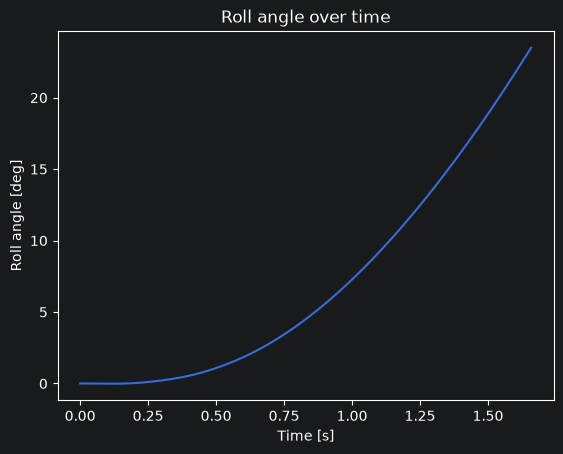

In [6]:
roll_t = dynamic_sol.structure.varphi[
    :, (coupled_system.structure.n_nodes - 1) // 2, 3]  # get rotation from varphi, [n_tstep]
t = jnp.arange(n_tstep) * coupled_system.aero.dt

fig, ax = plt.subplots()
ax.plot(t, jnp.rad2deg(roll_t))
ax.set_xlabel("Time [s]")
ax.set_ylabel("Roll angle [deg]")
ax.set_title("Roll angle over time")
plt.show()

## Save the results to view in Paraview

In [7]:
pvd_directories = dynamic_sol.plot(directory="./patil_output")